# Test d'Alexnet

- Creation : *29/12/2024*
- MàJ : *18/02/2025*

Analyser un pb du modèle dérivé d'AlexNet avec `.to(device)` ? A priori non...

# Modules

In [1]:
import torch
import torchvision
from torchvision import transforms as T

In [2]:
from datasets import DATASET_0, DATASET_2, CustomImageDataset, get_title, get_label_from_filename
from imagenet_labels import imagenet1K_names_to_labels
from utils import display_image_tensor as display_image_tensor_
from utils import alexnetfordeconv

In [3]:
# Spécifiquement pour un carnet de type Jupyter
def display_image_tensor(img_tensor, verbose=True):
    if display:
        display_image_tensor_(img_tensor, verbose=verbose, fn_display=display)

In [4]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


In [5]:
#geo_transforms = T.Compose([
#    T.Resize(256),
#    T.CenterCrop(224),
#])

#imagenet_mean = DATASET_0["means"]
#imagenet_std = DATASET_0["stds"]
#transforms = T.Compose([
#    T.Resize(256),
#    T.CenterCrop(224),
#    T.Lambda(lambda t: t/255.), # because read_image -> [0..255]
#    T.Normalize(mean=imagenet_mean, std=imagenet_std),
#])

transforms = torchvision.models.AlexNet_Weights.IMAGENET1K_V1.transforms()
print(transforms)

get_label = lambda f: get_label_from_filename(f, DATASET_2["path"], imagenet1K_names_to_labels)
dataset = CustomImageDataset(DATASET_2["path"], transform=transforms, extension="JPEG", dataloader_mode=True, get_label=get_label)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


0
Dimensions torch.Size([3, 224, 224]) 
Valeur min: -2.015155553817749 
Valeur max: 2.5005664825439453


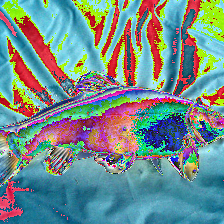

In [6]:
iter_dataset = iter(dataset)
image, label = next(iter_dataset)
print(label)
display_image_tensor(image)

In [7]:
batch_input = image.unsqueeze(dim=0).to(device)

## AlexNet standard

In [8]:
model_alexnet = torchvision.models.alexnet(weights='IMAGENET1K_V1')
model_alexnet.eval()
model_alexnet.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [9]:
result = model_alexnet(batch_input)
print(result.size())
print(result.argmax())

torch.Size([1, 1000])
tensor(0, device='mps:0')


## AlexNet pour déconvolution

In [10]:
model_alexnet_deconv = alexnetfordeconv(weights='IMAGENET1K_V1')
model_alexnet_deconv.eval()
model_alexnet_deconv.to(device)

AlexNetForDeconv(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bia

In [11]:
result = model_alexnet_deconv(batch_input)
print(result.size())
print(result.argmax())

torch.Size([1, 1000])
tensor(0, device='mps:0')


In [12]:
result = model_alexnet_deconv.forward_for_deconv(batch_input, -1, True)
print(result[1])
print(result[0])

[0] forward  Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
	 x.size: torch.Size([1, 64, 55, 55])
[1] forward  ReLU(inplace=True)
	 x.size: torch.Size([1, 64, 55, 55])
[2] forward  MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
	 x.size: torch.Size([1, 64, 27, 27])
[3] forward  Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
	 x.size: torch.Size([1, 192, 27, 27])
[4] forward  ReLU(inplace=True)
	 x.size: torch.Size([1, 192, 27, 27])
[5] forward  MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
	 x.size: torch.Size([1, 192, 13, 13])
[6] forward  Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
	 x.size: torch.Size([1, 384, 13, 13])
[7] forward  ReLU(inplace=True)
	 x.size: torch.Size([1, 384, 13, 13])
[8] forward  Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
	 x.size: torch.Size([1, 256, 13, 13])
[9] forward  ReLU(inplace=True)
	 x.size: torch.Size([1, 2

/Users/me/opt/anaconda3/envs/arena-env/lib/python3.11/site-packages/torch/_tensor_str.py:145: UserWarning: MPS: nonzero op is supported natively starting from macOS 14.0. Falling back on CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/mps/operations/Indexing.mm:361.)
  nonzero_finite_vals = torch.masked_select(


In [17]:
coord_activations = {
    2: [
        [0, 1, 10, 112],
        [0, 10, 25, 25],
        [0, 30, 50, 50]
    ],
    -1: [
        [0, 100, 2, 2],
        [0, 200, 4, 4],
    ]
}

for k, v in coord_activations.items():
    coord_count = len(v)
    coord_activations[k] = torch.tensor(v).repeat(batch_input.size(0), 1)
    coord_activations[k][:, 0] += torch.arange(0, batch_input.size(0)).view(batch_input.size(0), 1).repeat(1, coord_count).flatten()

print(coord_activations.items())

result = model_alexnet_deconv.get_activations(batch_input, coord_activations)
print(result)

dict_items([(2, tensor([[  0,   1,  10, 112],
        [  0,  10,  25,  25],
        [  0,  30,  50,  50]])), (-1, tensor([[  0, 100,   2,   2],
        [  0, 200,   4,   4]]))])
idx_probed_layers [2, 12]
> 2 2
> 12 -1
{2: tensor([3.3274, 0.3974, 0.0000], device='mps:0', grad_fn=<IndexBackward0>), -1: tensor([1.1371, 0.8909], device='mps:0', grad_fn=<IndexBackward0>)}
